# Clustering de documents

## Imports

In [88]:
import collections
import os
import string
import sys

import pandas as pd
from nltk import word_tokenize
from nltk.corpus import stopwords
from pprint import pprint
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine

In [89]:
import nltk

nltk.download('punkt')
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\elhaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\elhaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [90]:
data_path = "../../data/txt/"

## Choisir une décennie

In [91]:
DECADE = '1910'

## Charger tous les  fichiers de la décennie et en créer une liste de textes

In [92]:
files = [f for f in sorted(os.listdir(data_path)) if f"_{DECADE[:-1]}" in f]

In [96]:
# Exemple de fichiers
files[:5]

['KB_JB838_1910-01-06_01-00008.txt',
 'KB_JB838_1910-01-07_01-00003.txt',
 'KB_JB838_1910-01-09_01-00010.txt',
 'KB_JB838_1910-01-13_01-00007.txt',
 'KB_JB838_1910-01-16_01-00009.txt']

In [97]:
# Ouvre les fichiers texte de ma décennie et les lits 
# Texts devient une liste de documents, chacun représenté par une grande chaîne de caractères.
texts = [open(data_path + f, "r", encoding="utf-8").read() for f in files]

In [8]:
# Exemple de textes
texts[0][:400]

'V ’ \' ,^ïl\\* I KTTWrMlftfTi¥riM»irniiÉiin*ii> i ri rr r r iuvur n>miriiirianiiiinnnw n irirm mriToi i -- — ~ - . #* * ■ * i* ■ ■■ • »■ ma nr WT e EXTRACTION COMPLETEMENT SANS DOULEUR g e H’&H*"Ge»s** SOUWEINE 155, fie Utft la. \'- A1 « «i> ■■ 8 r - _ \'\' na, T\' DEI9TS DEP. 5 FS. maison do oonfiahtà, INSTITUT DENTAIRE DU80HEH, G2, rue de Louynln . Surpassa tout co que roua avez pu voir en Belgique, v'

## Vectoriser les documents à l'aide de TF-IDF

In [ ]:
# Création d'une fonction de pré-traitement
# Enlève la ponctuation, découpe le texte en tokens (mots individuels)
def preprocessing(text, stem=True):
    """ Tokenize text and remove punctuation """
    text = text.translate(string.punctuation)
    tokens = word_tokenize(text)
    return tokens

### Instancier le modèle TF-IDF avec ses arguments

In [10]:
vectorizer = TfidfVectorizer(
    tokenizer=preprocessing,
    stop_words=stopwords.words('french'),
    max_df=0.5,
    min_df=0.1,
    lowercase=True)

### Construire la matrice de vecteurs à l'aide de la fonction `fit_transform`

In [11]:
tfidf_vectors = vectorizer.fit_transform(texts)

c:\Users\elhaj\Github\tac\tac_venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [12]:
# Détail de la matrice
tfidf_vectors

<700x4042 sparse matrix of type '<class 'numpy.float64'>'
	with 576850 stored elements in Compressed Sparse Row format>

### Imprimer le vecteur tf-IDF du premier document

In [13]:
pd.Series(
    tfidf_vectors[0].toarray()[0],
    index=vectorizer.get_feature_names_out()
    ).sort_values(ascending=False)

ft             0.498859
vend           0.303463
piano          0.210893
pianos         0.185838
occas          0.125603
                 ...   
efforts        0.000000
eglise         0.000000
ei             0.000000
electricité    0.000000
♦              0.000000
Length: 4042, dtype: float64

## Comprendre les vecteurs et leurs "distances"

In [14]:
cosine([1, 2, 3], [1, 2, 3])

0

In [15]:
cosine([1, 2, 3], [1, 2, 2])

0.02004211298777725

In [16]:
cosine([1, 2, 3], [2, 2, 2])

0.07417990022744858

### Tests sur nos documents

In [17]:
tfidf_array = tfidf_vectors.toarray()

In [18]:
# Vecteur du document 0
tfidf_array[0]

array([0.01446701, 0.        , 0.        , ..., 0.04123556, 0.        ,
       0.        ])

In [19]:
# Vecteur du document 1
tfidf_array[1]

array([0.        , 0.        , 0.        , ..., 0.01786446, 0.06976965,
       0.        ])

In [20]:
cosine(tfidf_array[0], tfidf_array[1])

0.9465984121110094

## Appliquer un algorithme de clustering sur les vecteurs TF-IDF des documents

Pour en savoir plus sur le KMeans clustering :
- https://medium.com/dataseries/k-means-clustering-explained-visually-in-5-minutes-b900cc69d175

### Définir un nombre de clusters

In [63]:
N_CLUSTERS = 3

### Instancier le modèle K-Means et ses arguments

In [64]:
km_model = KMeans(n_clusters=N_CLUSTERS)

### Appliquer le clustering à l'aide de la fonction `fit_predict`

In [65]:
clusters = km_model.fit_predict(tfidf_vectors)

In [66]:
clustering = collections.defaultdict(list)

for idx, label in enumerate(clusters):
    clustering[label].append(files[idx])

In [67]:
pprint(dict(clustering))

{0: ['KB_JB838_1910-01-07_01-00003.txt',
     'KB_JB838_1910-01-17_01-00002.txt',
     'KB_JB838_1910-01-22_01-00003.txt',
     'KB_JB838_1910-01-22_01-00004.txt',
     'KB_JB838_1910-01-29_01-00003.txt',
     'KB_JB838_1910-01-30_01-00003.txt',
     'KB_JB838_1910-02-07_01-00002.txt',
     'KB_JB838_1910-02-09_01-00002.txt',
     'KB_JB838_1910-02-09_01-00004.txt',
     'KB_JB838_1910-02-18_01-00001.txt',
     'KB_JB838_1910-02-24_01-00003.txt',
     'KB_JB838_1910-02-25_01-00002.txt',
     'KB_JB838_1910-03-05_01-00008.txt',
     'KB_JB838_1910-03-06_01-00005.txt',
     'KB_JB838_1910-03-16_02-00001.txt',
     'KB_JB838_1910-03-19_01-00003.txt',
     'KB_JB838_1910-03-28_01-00004.txt',
     'KB_JB838_1910-04-02_01-00004.txt',
     'KB_JB838_1910-04-10_01-00001.txt',
     'KB_JB838_1910-04-12_01-00003.txt',
     'KB_JB838_1910-04-17_01-00002.txt',
     'KB_JB838_1910-04-29_01-00003.txt',
     'KB_JB838_1910-04-29_01-00004.txt',
     'KB_JB838_1910-04-30_01-00002.txt',
     'KB_JB838_1

## Visualiser les clusters

### Réduire les vecteurs à 2 dimensions à l'aide de l'algorithme PCA
Cette étape est nécessaire afin de visualiser les documents dans un espace 2D

https://fr.wikipedia.org/wiki/Analyse_en_composantes_principales

In [68]:
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(tfidf_vectors.toarray())

In [69]:
reduced_vectors[:10]

array([[ 0.10868873, -0.53281297],
       [-0.33264547,  0.12563927],
       [ 0.22466641, -0.33757388],
       [ 0.59928262,  0.30194223],
       [ 0.41641512, -0.00363842],
       [-0.29016048,  0.10669739],
       [-0.25422701,  0.03886942],
       [-0.14122682, -0.12073671],
       [-0.28880104,  0.074674  ],
       [-0.2677993 ,  0.05373395]])

### Générer le plot

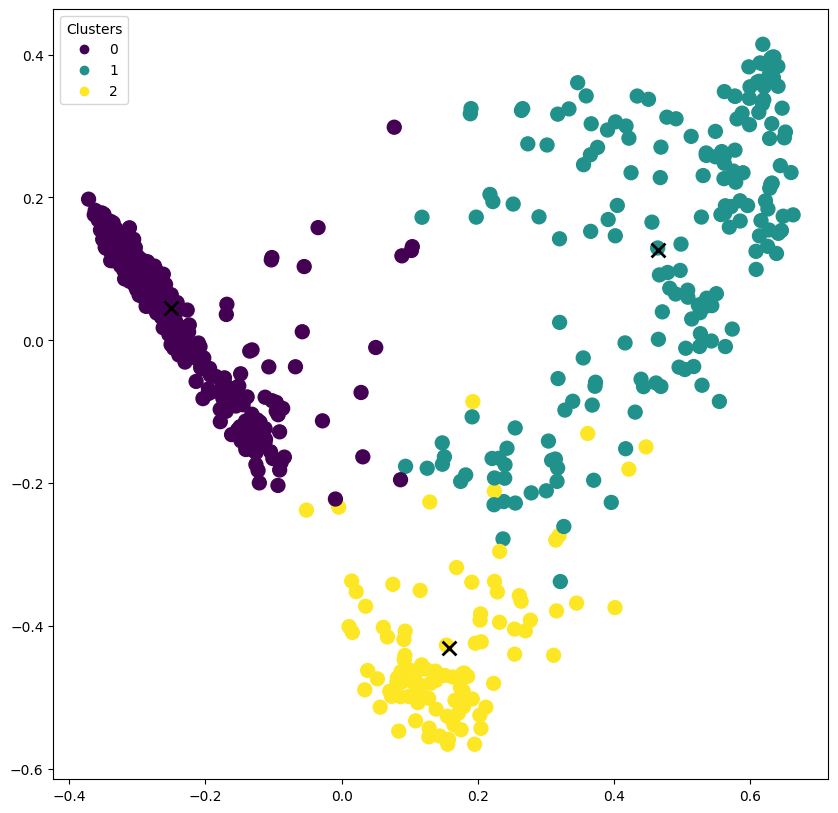

In [70]:
x_axis = reduced_vectors[:, 0]
y_axis = reduced_vectors[:, 1]

plt.figure(figsize=(10,10))
scatter = plt.scatter(x_axis, y_axis, s=100, c=clusters)

# Ajouter les centroïdes
centroids = pca.transform(km_model.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],  marker = "x", s=100, linewidths = 2, color='black')

# Ajouter la légende
plt.legend(handles=scatter.legend_elements()[0], labels=set(clusters), title="Clusters")

# Word Embeddings : le modèle Word2Vec

In [4]:
import sys

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec

import nltk
from nltk.tokenize import wordpunct_tokenize
from unidecode import unidecode

## Chargement et traitement des phrases du corpus

### Création d'un objet qui *streame* les lignes d'un fichier pour économiser de la RAM

In [5]:
class MySentences(object):
    """Tokenize and Lemmatize sentences"""
    def __init__(self, filename):
        self.filename = filename

    def __iter__(self):
        for line in open(self.filename, encoding='utf-8', errors="backslashreplace"):
            yield [unidecode(w.lower()) for w in wordpunct_tokenize(line)]

In [6]:
infile = f"../../data/sents.txt"
sentences = MySentences(infile)

### Détection des bigrams

In [7]:
bigram_phrases = Phrases(sentences)

In [8]:
type(bigram_phrases.vocab)

dict

In [9]:
len(bigram_phrases.vocab.keys())

15850647

### Conversion des `Phrases` en objet `Phraser`

In [10]:
bigram_phraser = Phraser(phrases_model=bigram_phrases)

### Extraction des trigrams

Nous répétons l'opération en envoyant cette fois la liste de bigrams afin d'extraire les trigrams.

In [12]:
trigram_phrases = Phrases(bigram_phraser[sentences])

In [13]:
trigram_phraser = Phraser(phrases_model=trigram_phrases)

### Création d'un corpus d'unigrams, bigrams, trigrams

In [14]:
corpus = list(trigram_phraser[bigram_phraser[sentences]])

## Entrainement des modèle Word2Vec sur ce corpus

### Modèle 1

In [46]:
%%time
M1 = Word2Vec(
    corpus, # On passe le corpus de ngrams que nous venons de créer
    vector_size=32, # Le nombre de dimensions dans lesquelles le contexte des mots devra être réduit, aka. vector_size
    window=15, # La taille du "contexte", ici 15 mots avant et après le mot observé, contexte très large
    min_count=5, # On ignore les mots qui n'apparaissent pas au moins 5 fois dans le corpus
    workers=4, # Permet de paralléliser l'entraînement du modèle en 4 threads
    epochs=5 # Nombre d'itérations du réseau de neurones sur le jeu de données pour ajuster les paramètres avec la descente de gradient, aka. epochs.
)

# Sauvegarde du modèle
outfile = f"../../data/M1.model"
M1.save(outfile)

CPU times: total: 18min 44s
Wall time: 6min


### Modèle 2

In [49]:
%%time
M2 = Word2Vec(
    corpus, # On passe le corpus de ngrams que nous venons de créer
    vector_size=32, # Le nombre de dimensions dans lesquelles le contexte des mots devra être réduit, aka. vector_size
    window=2, # La taille du "contexte", ici 2 mots avant et après le mot observé, contexte très restreint
    min_count=5, # On ignore les mots qui n'apparaissent pas au moins 5 fois dans le corpus
    workers=4, # Permet de paralléliser l'entraînement du modèle en 4 threads
    epochs=5 # Nombre d'itérations du réseau de neurones sur le jeu de données pour ajuster les paramètres avec la descente de gradient, aka. epochs.
)

# Sauvegarde du modèle
outfile = f"../../data/M2.model"
M2.save(outfile)

CPU times: total: 14min 12s
Wall time: 4min 52s


### Modèle 3

In [48]:
%%time
M3 = Word2Vec(
    corpus, # On passe le corpus de ngrams que nous venons de créer
    vector_size=32, # Le nombre de dimensions dans lesquelles le contexte des mots devra être réduit, aka. vector_size
    window=5, # La taille du "contexte", ici 5 mots avant et après le mot observé
    min_count=2, # On ignore les mots qui n'apparaissent pas au moins 2 fois dans le corpus, on garde les mots rares
    workers=4, # Permet de paralléliser l'entraînement du modèle en 4 threads
    epochs=5 # Nombre d'itérations du réseau de neurones sur le jeu de données pour ajuster les paramètres avec la descente de gradient, aka. epochs.
)

# Sauvegarde du modèle
outfile = f"../../data/M3.model"
M3.save(outfile)

CPU times: total: 23min 32s
Wall time: 6min 47s


## Explorer les modèles

### Charger les modèles  en mémoire

In [50]:
model1 = Word2Vec.load("../../data/M1.model")
model2 = Word2Vec.load("../../data/M2.model")
model3 = Word2Vec.load("../../data/M3.model")

### Calculer la similarité entre deux termes

In [71]:
model1.wv.similarity("guerre", "soldat")

0.34515756

In [72]:
model2.wv.similarity("guerre", "soldat")

0.3727051

In [73]:
model3.wv.similarity("guerre", "soldat")

0.32784685

### Chercher les mots les plus proches d'un terme donné

In [74]:
model1.wv.most_similar("soldat", topn=10)

[('bourreau', 0.9015893340110779),
 ('prisonnier', 0.87680983543396),
 ('pretre', 0.8517184257507324),
 ('soldat_belge', 0.8447815179824829),
 ('compagnon', 0.8390979170799255),
 ('traitre', 0.8387477993965149),
 ('bagne', 0.8362236022949219),
 ('navigateur', 0.8217195868492126),
 ('camarade', 0.821361780166626),
 ('soldai', 0.8206177949905396)]

In [65]:
model2.wv.most_similar("soldat", topn=10)

[('pretre', 0.9178184866905212),
 ('policier', 0.9139528274536133),
 ('paysan', 0.9129769802093506),
 ('matelot', 0.9057899117469788),
 ('gaillard', 0.9035488963127136),
 ('traitre', 0.9030200242996216),
 ('patriote', 0.902021586894989),
 ('juif', 0.901779294013977),
 ('poete', 0.8948903679847717),
 ('philosophe', 0.8916725516319275)]

In [66]:
model3.wv.most_similar("soldat", topn=10)

[('bourreau', 0.9069249033927917),
 ('prisonnier', 0.9015809893608093),
 ('pretre', 0.9001549482345581),
 ('policier', 0.8878626227378845),
 ('paysan', 0.8720324039459229),
 ('matelot', 0.8693546056747437),
 ('compagnon', 0.8644547462463379),
 ('marin', 0.8592474460601807),
 ('martyr', 0.8586810827255249),
 ('cavalier', 0.8555089235305786)]

## Explorer le modèle 3

### Calculer la similarité entre deux termes

In [79]:
model3.wv.similarity("guerre", "ville")

0.5016991

In [78]:
model3.wv.similarity("guerre", "piano")

-0.13655108

In [82]:
model3.wv.similarity("agriculture", "roi")

0.33441788

### Chercher les mots les plus proches d'un terme donné

In [85]:
model3.wv.most_similar("proces", topn=10)

[('jury', 0.8977044820785522),
 ('jugement', 0.8925244808197021),
 ('verdict', 0.8738618493080139),
 ('foreign_office', 0.8496547341346741),
 ('conseil_municipal', 0.8400394916534424),
 ('renvoi', 0.8370895981788635),
 ('referendum', 0.8358943462371826),
 ('tribunal_militaire', 0.8295633792877197),
 ('message', 0.8282965421676636),
 ('telegramme', 0.8281367421150208)]

In [86]:
model3.wv.most_similar("reine", topn=10)

[('chevalerie', 0.8720933794975281),
 ('princesse', 0.8670520186424255),
 ('heine', 0.8487674593925476),
 ('creche', 0.8453208208084106),
 ('royaute', 0.8365657925605774),
 ('fayette', 0.8337472081184387),
 ('princesse_clementine', 0.8337036371231079),
 ('fiancee', 0.8270772695541382),
 ('galerie_giroux', 0.81270831823349),
 ('reino', 0.8124473690986633)]

In [87]:
model3.wv.most_similar("arme", topn=10)

[('embarcation', 0.8595297336578369),
 ('epaule', 0.8482006788253784),
 ('individu', 0.8400149345397949),
 ('imprudence', 0.8347160816192627),
 ('echelle', 0.8337461948394775),
 ('alarme', 0.8316895961761475),
 ('epave', 0.8279300928115845),
 ('engin', 0.8270950317382812),
 ('ivresse', 0.8202695250511169),
 ('explosion', 0.8188211917877197)]